In [69]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Execute with time limit.

In [70]:
%%bash
dirname=data/1
filename=${dirname}/first_order_decay.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_decay.sbml
lm_setp ${filename} writeInterval=1e-2 maxTime=1e1
echo "Executing the command in `pwd`:"
lmes -r 1-1000 -f ${filename} -gr 0 -c 4 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/first_order_decay.lm:
maxTime=1e1
writeInterval=1e-2
Done.
Executing the command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_decay:
Finished.


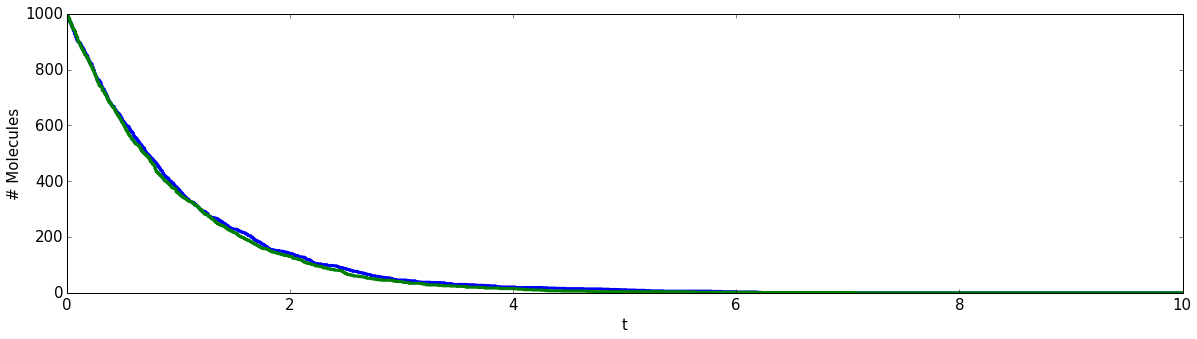

In [71]:
# Plot the time series for a single replicate.
dirname="data/1"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
replicate=1
counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
step(times,counts, **stepStyles)
replicate=2
counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
step(times,counts, **stepStyles)
xlabel('t'); ylabel('# Molecules')

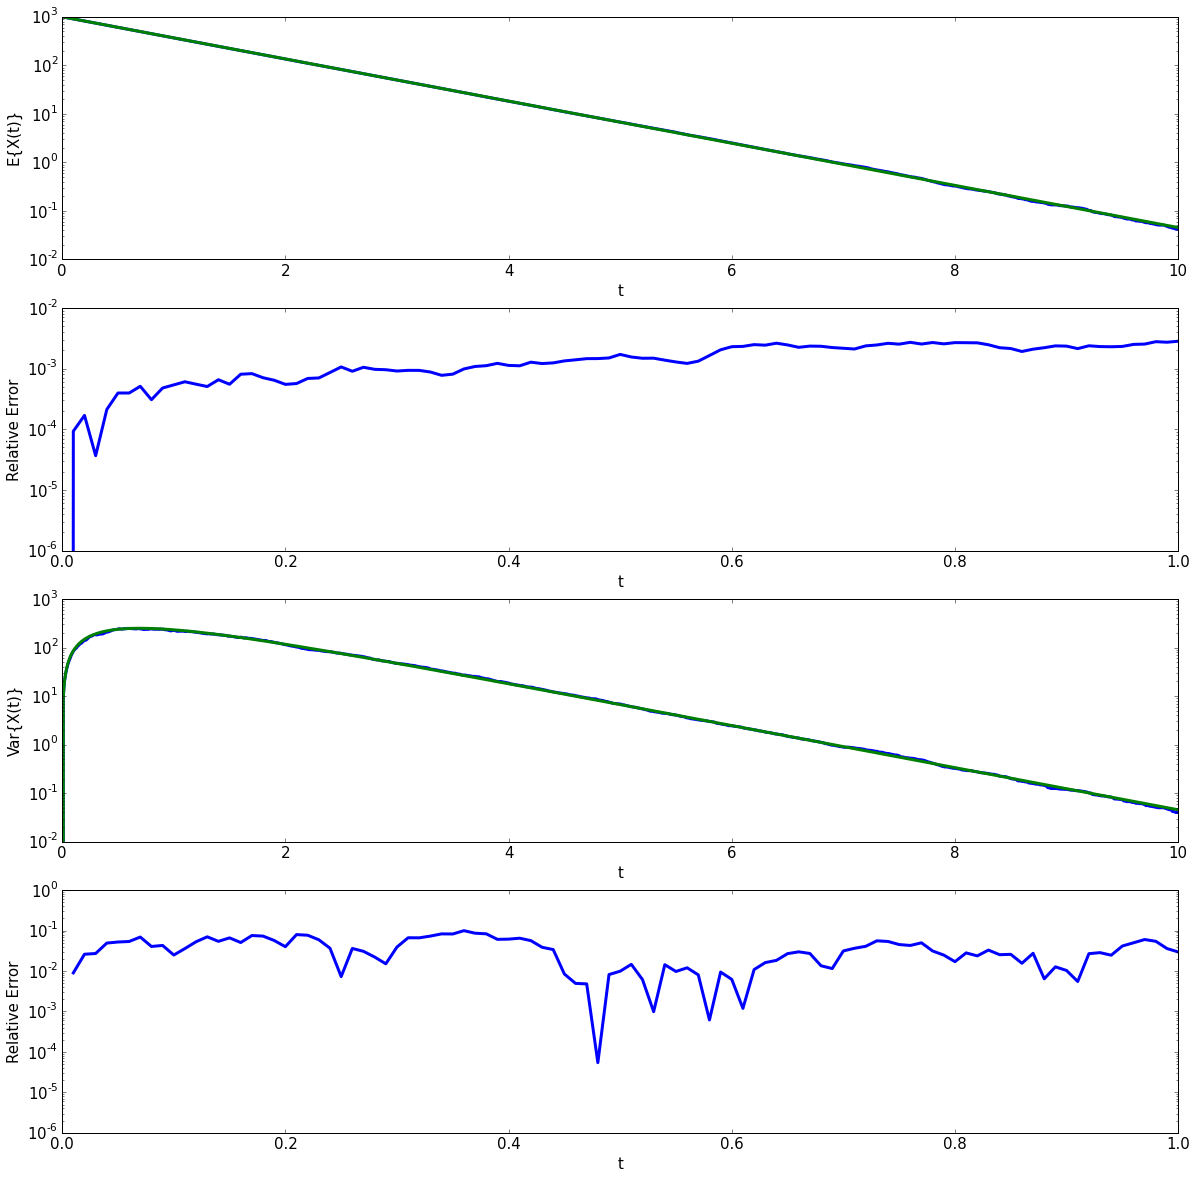

In [74]:
# Plot the accuracy of the mean and variance.
dirname="data/1"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
replicates=fp["/Simulations"].keys()
k=0
mSim=None
vSim=None
times=None
for replicate in replicates:
    if times is None:
        times = np.zeros(fp["/Simulations/%s/SpeciesCountTimes"%replicate].shape, dtype=double)
        times += fp["/Simulations/%s/SpeciesCountTimes"%replicate]
    counts=fp["/Simulations/%s/SpeciesCounts"%replicate]
    if mSim is None:
        k += 1
        mSim = np.zeros(counts.shape, dtype=double)
        mSim[:,:] = counts
        vSim = np.zeros(counts.shape, dtype=double)
    else:
        k += 1
        mSim = mSim + (counts-mSim)/k
        vSim = vSim + (counts-mSim)*(counts-mSim)

vSim /= (k-1)

ax=plt.subplot(4,1,1)
plt.plot(times,mSim, **plotStyles)
plt.plot(times,mTheory, **plotStyles)
ax.set_yscale('log'); xlabel('t'); ylabel('E{X(t)}')

ax=plt.subplot(4,1,2)
A0=mSim[0]
k=1.0
mTheory=np.zeros(mSim.shape, dtype=double)
mTheory[:,0]=A0*exp(-k*times)
plt.plot(times,abs(mSim-mTheory)/mTheory, **plotStyles)
ax.set_yscale('log'); xlim([0,1]); ylim([1e-6,1e-2]); xlabel('t'); ylabel('Relative Error')

ax=plt.subplot(4,1,3)
plt.plot(times,vSim, **plotStyles)
plt.plot(times,vTheory, **plotStyles)
ax.set_yscale('log'); xlabel('t'); ylabel('Var{X(t)}')

ax=plt.subplot(4,1,4)
vTheory=np.zeros(vSim.shape, dtype=double)
vTheory[:,0]=A0*exp(-k*times)*(1-exp(-k*times))
plt.plot(times,abs(vSim-vTheory)/vTheory, **plotStyles)
ax.set_yscale('log'); xlim([0,1]); ylim([1e-6,1e-0]); xlabel('t'); ylabel('Relative Error')

pass

### Execute with no limits

In [1]:
%%bash
dirname=data/2
filename=${dirname}/first_order_decay.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_decay.sbml
lm_setp ${filename} writeInterval=1e-2
echo "Executing the command in `pwd`:"
echo lmes -r 1-1000 -f ${filename} -gr 0 -c 4
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/first_order_decay.lm:
writeInterval=1e-2
Done.
Executing the command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_decay:
lmes -r 1-1000 -f data/1/first_order_decay.lm -gr 0 -c 4
Finished.


### Execute with lower species limit

In [75]:
%%bash
dirname=data/3
filename=${dirname}/first_order_decay.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_decay.sbml
lm_setp ${filename} writeInterval=1e-2 maxTime=1e1 "speciesLowerLimitList=0:150"
echo "Executing the command in `pwd`:"
lmes -r 1-10000 -f ${filename} -gr 0 -c 4 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/3/first_order_decay.lm:
maxTime=1e1
speciesLowerLimitList=0:150
writeInterval=1e-2
Done.
Executing the command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_decay:
Finished.


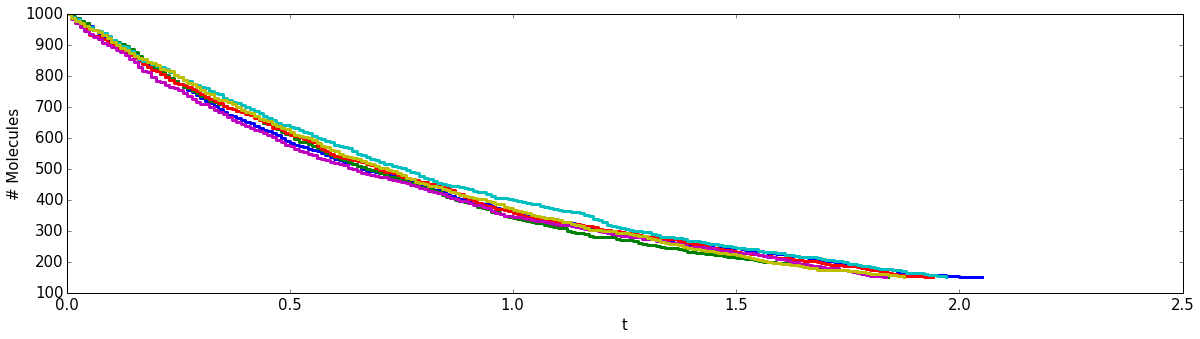

In [76]:
# Plot the time series for a set of replicates.
dirname="data/3"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
for replicate in (1,2,3,4,5,6):
    counts=fp["/Simulations/%07d/SpeciesCounts"%replicate]
    times=fp["/Simulations/%07d/SpeciesCountTimes"%replicate]
    step(times,counts, **stepStyles)
xlabel('t'); ylabel('# Molecules')
pass

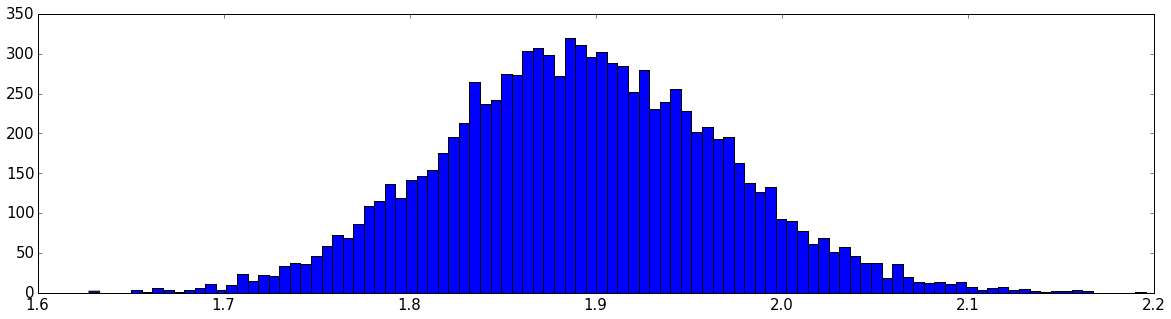

In [77]:
# Plot the final times.
dirname="data/3"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
finalTimes=[]
for replicate in replicates:
    counts = fp["/Simulations/%s/SpeciesCounts"%replicate]
    times = fp["/Simulations/%s/SpeciesCountTimes"%replicate]
    if counts[-1] != 150:
        print "Final count was not correct %d=%d"%(replicate,counts[-1])
    else:
        finalTimes.append(times[-1])
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
hist(finalTimes,100)
pass

### Execute tracking FPT

In [78]:
%%bash
dirname=data/4
filename=${dirname}/first_order_decay.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_decay.sbml
lm_setp ${filename} maxTime=1e2 fptTrackingList=0
echo "Executing the command in `pwd`:"
lmes -r 1-10000 -f ${filename} -gr 0 -c 4 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/4/first_order_decay.lm:
fptTrackingList=0
maxTime=1e2
Done.
Executing the command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_decay:
Finished.


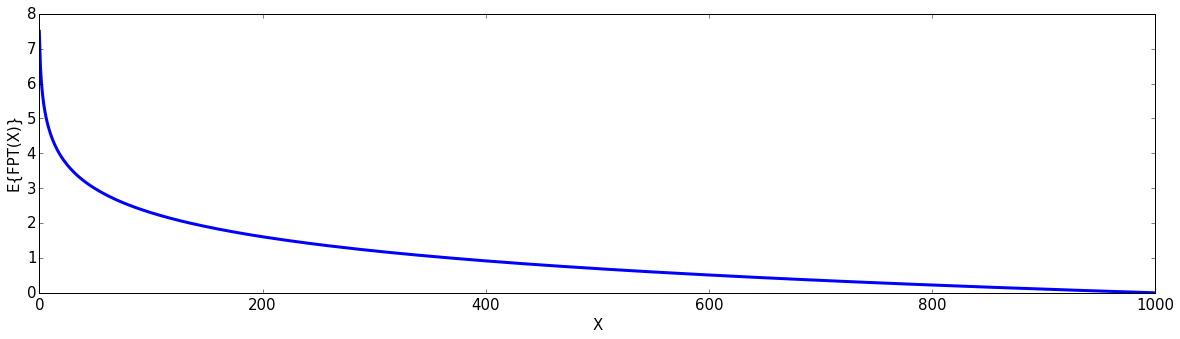

In [79]:
# Plot the mean first passage times.
dirname="data/4"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
counts=None
times=None
for replicate in replicates:
    if counts is None:
        counts=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Counts"%replicate], dtype=double)
        times=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Times"%replicate], dtype=double)
    else:
        counts+=fp["/Simulations/%s/FirstPassageTimes/00/Counts"%replicate]
        times+=fp["/Simulations/%s/FirstPassageTimes/00/Times"%replicate]
counts /= float(len(replicates))
times /= float(len(replicates))
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
ax=plt.subplot(1,1,1)
plt.plot(counts,times, **plotStyles)
ax.set_yscale('linear'); xlabel('X'); ylabel('E{FPT(X)}')
pass

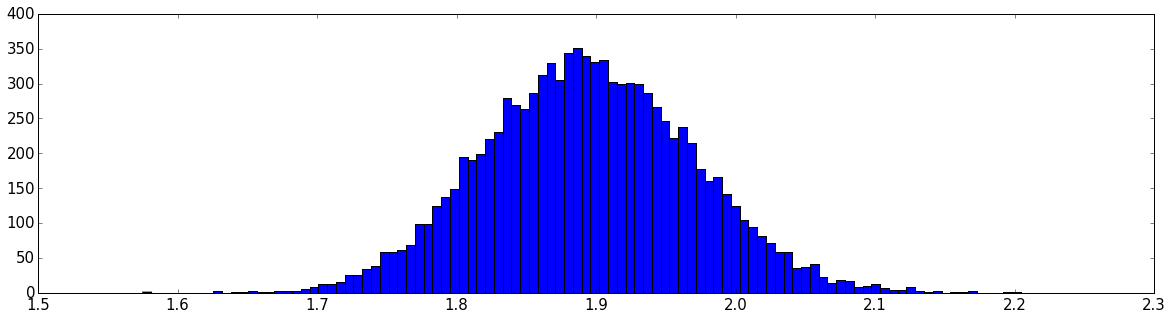

In [81]:
# Plot the time to a specific count.
X=150
dirname="data/4"
filename="%s/first_order_decay.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
finalTimes=[]
for replicate in replicates:
    counts=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Counts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Times"%replicate], dtype=double)
    if counts[X] != X:
        print "Final count was not correct %d=%d"%(replicate,counts[X])
    else:
        finalTimes.append(times[X])
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
hist(finalTimes,100)
pass